# MMRAD PET/CT Unified Evaluation Plots

This notebook mirrors the AE plotting workflow for paper comparison figures. Slice scores are always `topk_from_map` from each method's anomaly map.

## 0. Imports

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
from IPython.display import display

CWD = Path.cwd().resolve()
if CWD.name == "MMRAD_successful":
    METHOD_DIR = CWD
    PROJECT_ROOT = CWD.parent
else:
    METHOD_DIR = CWD / "MMRAD_successful"
    PROJECT_ROOT = CWD
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from paper_eval_utils import (
    cache_output_paths,
    cache_value,
    full_evaluation_from_cache,
    load_eval_cache,
    parse_modalities,
    plot_confusion_matrices,
    plot_roc_pr_panel,
    plot_score_distribution,
    plot_threshold_analysis,
    set_plot_style,
)

set_plot_style()


## 1. Parameter Configuration

In [ ]:
# ---------- Paths and data ----------
METHOD = "MMRAD"
METHOD_NAME = "MMRAD"
DATA_ROOT = "A_data/2d_equal_mask50"
DATA_ROOT_PATH = (PROJECT_ROOT / DATA_ROOT).resolve()
TRACER = "PSMA"          # "PSMA" or "FDG"
MODALITIES = "ct,pet"    # "pet", "ct", or "ct,pet"
DEVICE = "cuda:2"
TOPK_PERCENT = 1.0       # Main paper setting: small-lesion top-k mean from anomaly map.
FORCE_RECOMPUTE = False # False: reuse test_cache.npz; True: rerun slow inference.
EXTRA_ARGS = []          # Example: ["--checkpoint", "path/to/checkpoint.pth"]

# ---------- Metric and plot settings ----------
REPORT_SPEC_TARGETS = (0.95, 0.90)
CM_SPEC_TARGET = 0.95
PLOT_CM_THRESHOLDS = ["youden", "f1_max", "spec_95"]
SKIP_AUPRO = True        # AUPRO can be slow; keep skipped unless needed for the paper table.
EVAL_NSTRIPS = 200

modalities = parse_modalities(MODALITIES)
CACHE_FILE, METRICS_FILE, OUT_DIR = cache_output_paths(METHOD, TRACER, modalities)
TITLE_PREFIX = f"{TRACER.upper()} {'+'.join(modalities).upper()}"

print("METHOD_DIR:", METHOD_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT_PATH:", DATA_ROOT_PATH)
print("CACHE_FILE:", CACHE_FILE)
print("METRICS_FILE:", METRICS_FILE)
print("OUT_DIR:", OUT_DIR)


METHOD_DIR: /data/cyf/codes/lyh/MMRAD_successful
PROJECT_ROOT: /data/cyf/codes/lyh
DATA_ROOT_PATH: /data/cyf/codes/lyh/A_data/2d_equal_mask50
CACHE_FILE: /data/cyf/codes/lyh/paper_figures/MMRAD/plot_cache/PSMA_ct_pet/test_cache.npz
METRICS_FILE: /data/cyf/codes/lyh/paper_figures/MMRAD/plot_cache/PSMA_ct_pet/metrics.json
OUT_DIR: /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet


## 2. Load or Generate Inference Cache

In [3]:
print(f"CACHE_FILE exists: {CACHE_FILE.exists()}  |  FORCE_RECOMPUTE={FORCE_RECOMPUTE}")
if FORCE_RECOMPUTE or not CACHE_FILE.exists():
    cmd = [
        sys.executable, str(METHOD_DIR / "infer.py"),
        "--data_root", str(DATA_ROOT_PATH),
        "--tracer", TRACER,
        "--modalities", MODALITIES,
        "--device", DEVICE,
        "--topk_percent", str(TOPK_PERCENT),
        "--make_cache",
        *EXTRA_ARGS,
    ]
    print("Running:", " ".join(cmd))
    t0 = time.time()
    subprocess.run(cmd, cwd=str(METHOD_DIR), check=True)
    print(f"Generated cache in {time.time() - t0:.1f}s")
else:
    print("Using existing cache; no slow inference will be run.")

cache = load_eval_cache(CACHE_FILE, topk_percent=TOPK_PERCENT)
print("Slices:", len(cache["slice_labels"]))
print("Pixel maps:", cache["pixel_maps"].shape)
print("Patients:", len(np.unique(cache["patient_ids"])))
print("Score source:", cache_value(cache, "score_source", "unknown"))
print("Top-k percent:", cache_value(cache, "topk_percent", TOPK_PERCENT))


CACHE_FILE exists: False  |  FORCE_RECOMPUTE=True
Running: /data/ubuntu_conda/envs/anyad/bin/python /data/cyf/codes/lyh/MMRAD_successful/infer.py --data_root /data/cyf/codes/lyh/A_data/2d_equal_mask50 --tracer PSMA --modalities ct,pet --device cuda:2 --topk_percent 1.0 --make_cache
Loaded checkpoint: /data/cyf/codes/lyh/MMRAD_successful/checkpoints/PSMA/ct_pet/model.pth


MMRAD cache: 100%|██████████████████████████| 1622/1622 [03:51<00:00,  6.99it/s]


Cache saved: /data/cyf/codes/lyh/paper_figures/MMRAD/plot_cache/PSMA_ct_pet/test_cache.npz
Generated cache in 364.2s
Slices: 1622
Pixel maps: (1622, 256, 256)
Patients: 36
Score source: topk_from_map
Top-k percent: 1.0


## 3. Slice / Patient / Pixel Metrics

In [4]:
print("Computing slice / patient / pixel metrics...")
t0 = time.time()
evaluation = full_evaluation_from_cache(
    cache,
    method=METHOD_NAME,
    tracer=TRACER,
    modalities=modalities,
    metrics_file=METRICS_FILE,
    topk_percent=TOPK_PERCENT,
    report_spec_targets=REPORT_SPEC_TARGETS,
    operating_spec=CM_SPEC_TARGET,
    skip_aupro=SKIP_AUPRO,
    device=DEVICE,
    nstrips=EVAL_NSTRIPS,
)
print(f"Metrics computed in {time.time() - t0:.1f}s")
print(json.dumps(evaluation["summary"], indent=2))


Computing slice / patient / pixel metrics...
[Eval] Step 1/4: slice-level binary metrics ...
[Eval] Step 2/4: patient-level binary metrics ...
[Eval] Step 3/4: pixel-level metrics (all slices) ...
[Eval] Step 4/4: pixel-level metrics (abnormal slices only) ...
Metrics computed in 206.3s
{
  "method": "MMRAD",
  "tracer": "PSMA",
  "modalities": [
    "ct",
    "pet"
  ],
  "cm_operating_spec": 0.95,
  "report_spec_targets": [
    0.95,
    0.9
  ],
  "score_source": "topk_from_map",
  "topk_percent": 1.0,
  "slice": {
    "auroc": 0.7418105336155923,
    "ap": 0.7428475513336521,
    "f1_max": 0.7180246913575472,
    "f1_threshold": 0.2787349224090576,
    "youden_threshold": 0.3000829815864563,
    "youden_index": 0.3310643112635959,
    "sens_at_95spec": 0.2781954887218045,
    "thr_at_95spec": 0.44258615374565125,
    "sens_at_90spec": 0.37719298245614036,
    "thr_at_90spec": 0.4086524248123169,
    "operating_spec": 0.95,
    "operating_threshold": 0.44258615374565125,
    "accura

## 4. ROC and PR Curves

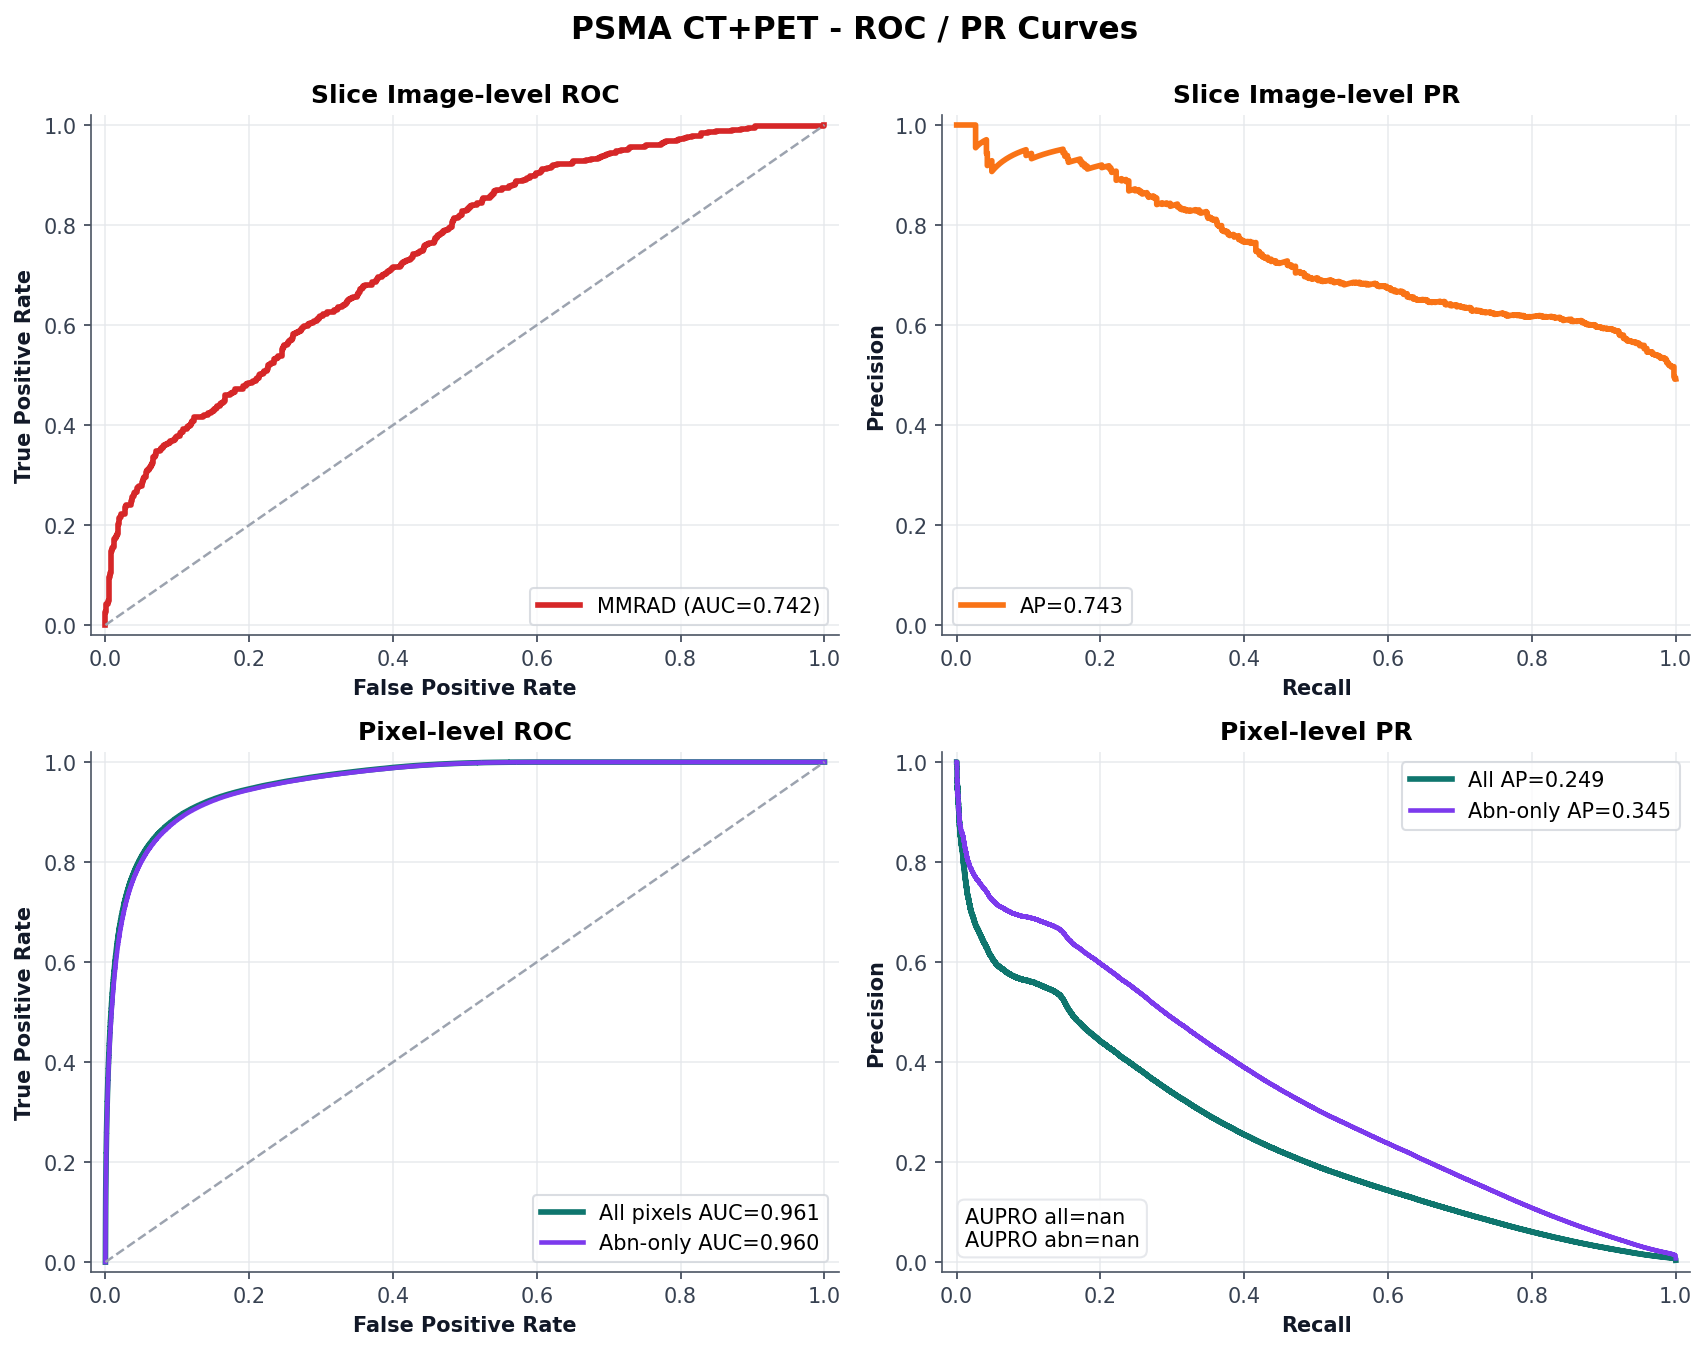

PosixPath('/data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/single_method_roc_pr_panel.png')

In [5]:
plot_roc_pr_panel(
    evaluation,
    method=METHOD_NAME,
    title_prefix=TITLE_PREFIX,
    path=OUT_DIR / "single_method_roc_pr_panel.png",
    display_fn=display,
)


## 5. Multi-threshold Confusion Matrices

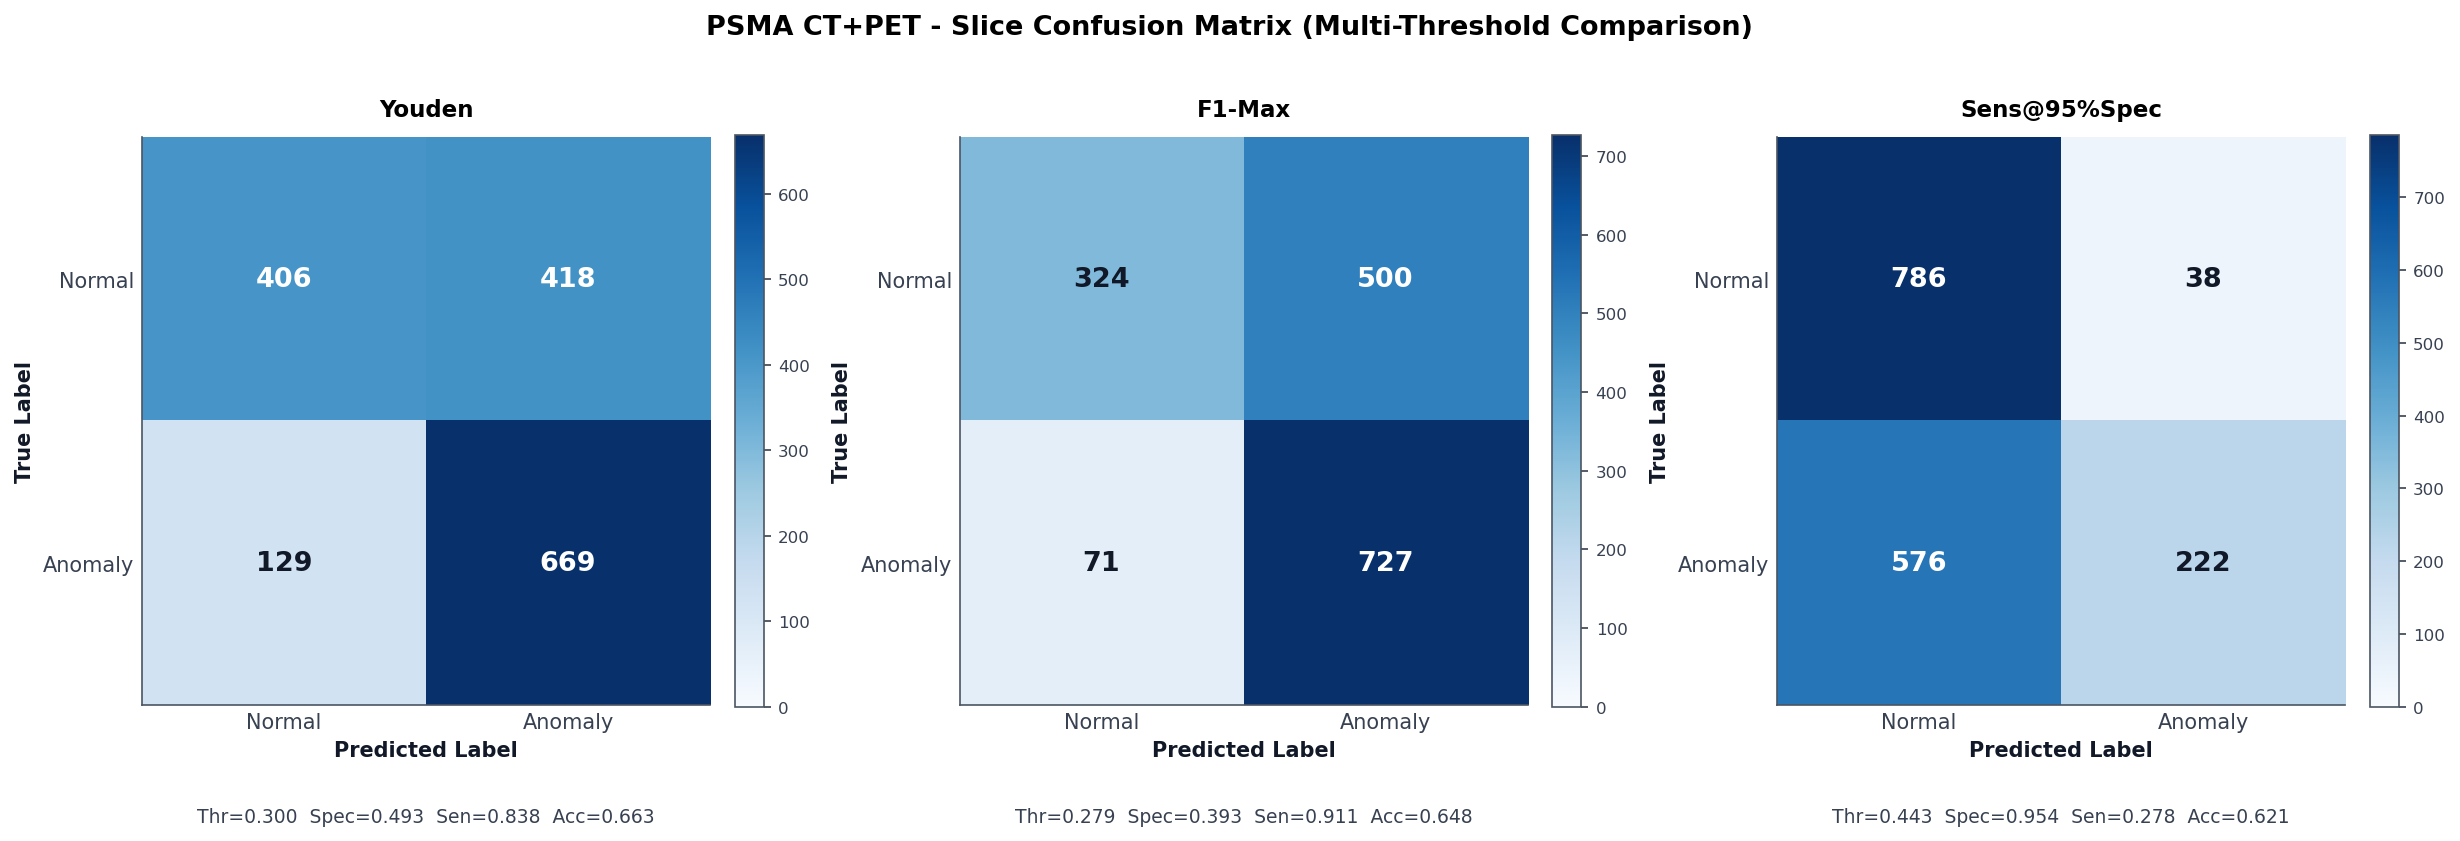

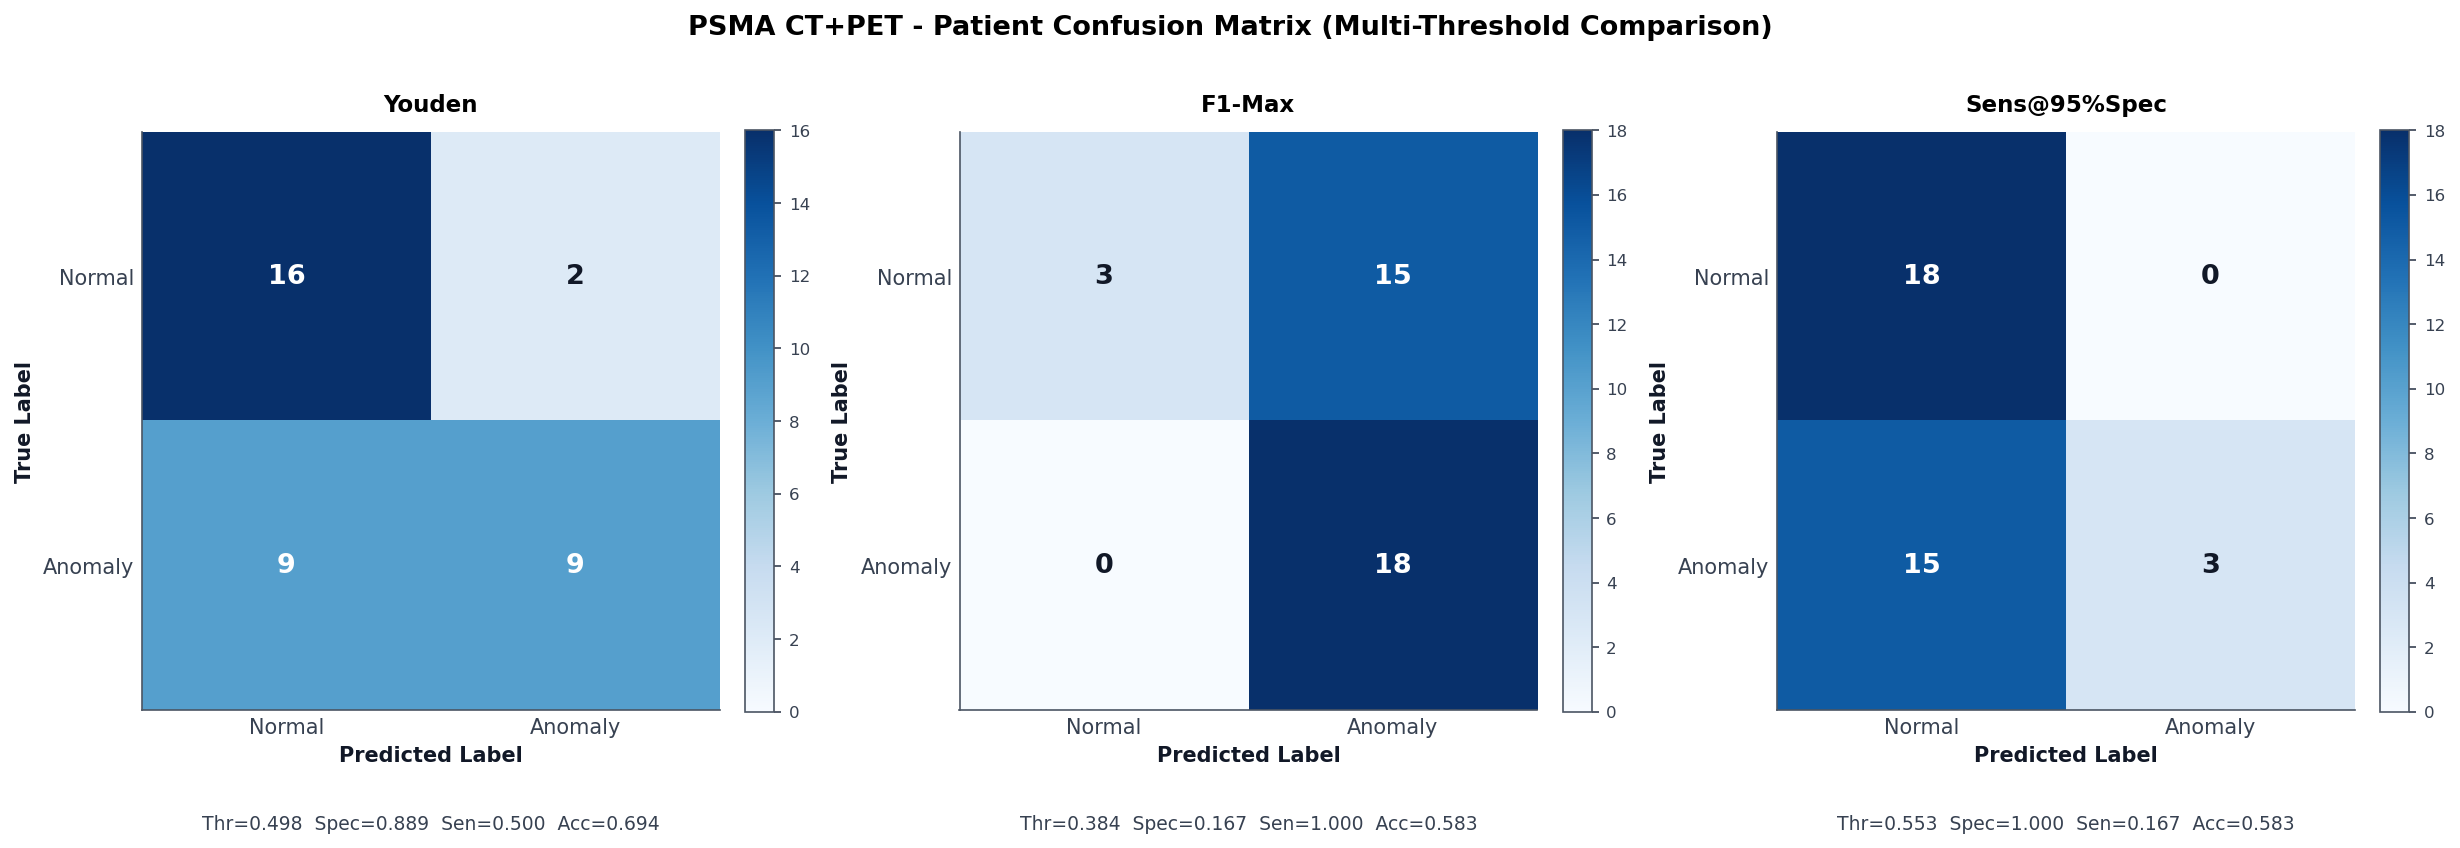

[PosixPath('/data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/confusion_matrix_slice_multi_threshold.png'),
 PosixPath('/data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/confusion_matrix_patient_multi_threshold.png')]

In [6]:
plot_confusion_matrices(
    evaluation,
    title_prefix=TITLE_PREFIX,
    out_dir=OUT_DIR,
    thresholds=PLOT_CM_THRESHOLDS,
    operating_spec=CM_SPEC_TARGET,
    display_fn=display,
)


## 6. Score Distribution

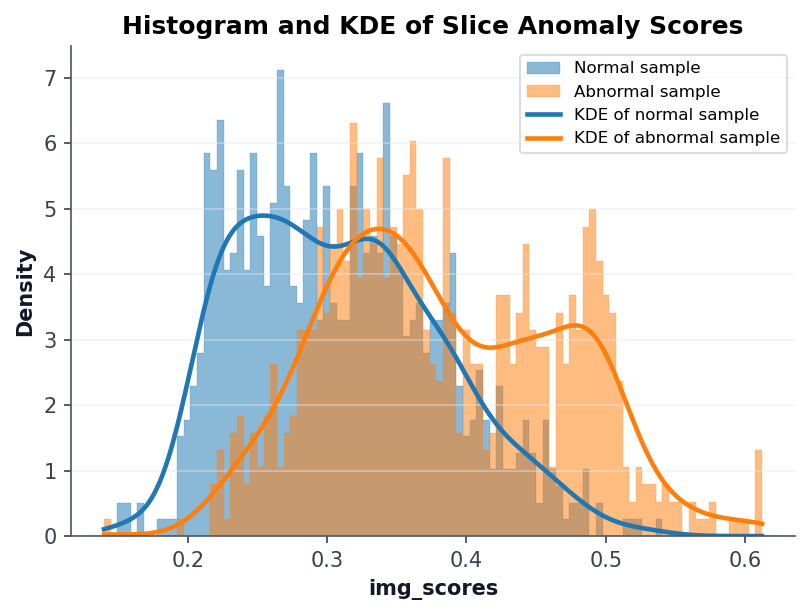

PosixPath('/data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/score_distribution.png')

In [7]:
plot_score_distribution(
    evaluation,
    path=OUT_DIR / "score_distribution.png",
    display_fn=display,
)


## 7. Threshold Analysis

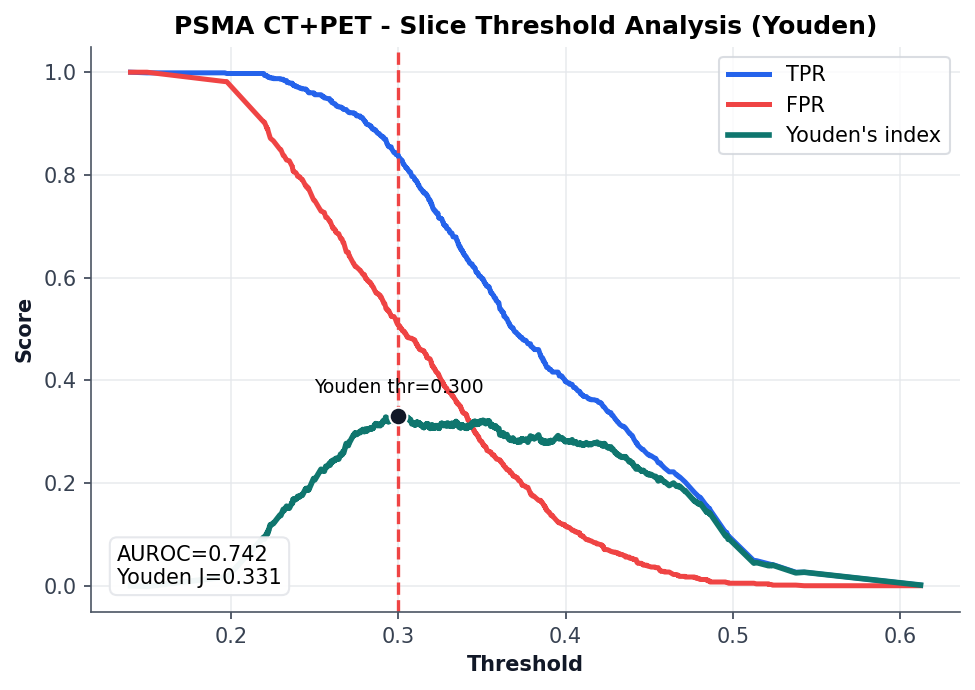

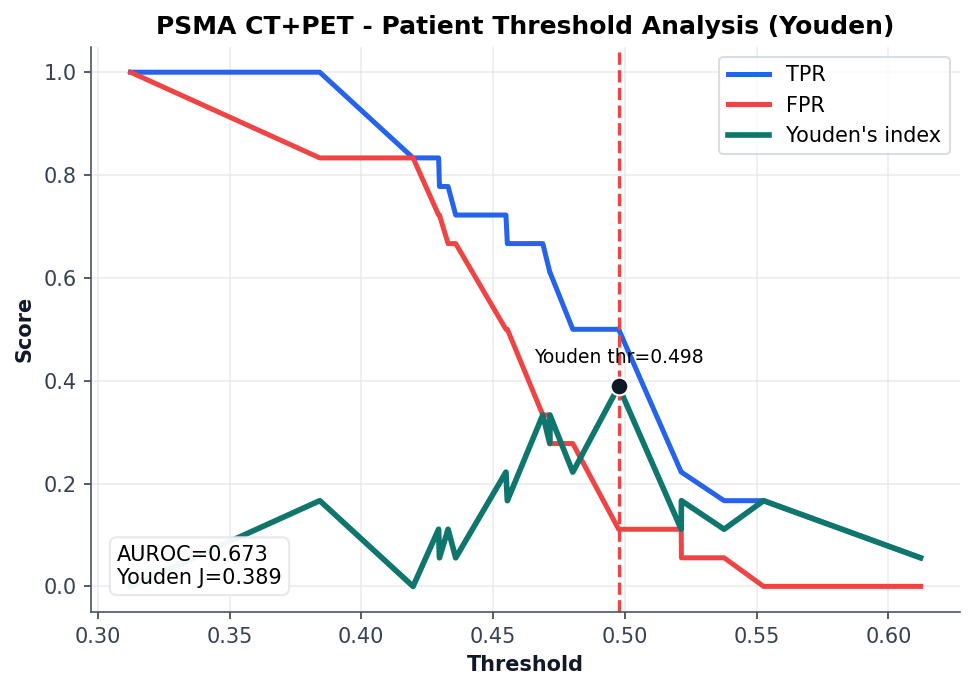

In [8]:
if evaluation["slice_metrics"].get("youden_curve") is not None:
    plot_threshold_analysis(
        evaluation["slice_metrics"]["youden_curve"],
        evaluation["slice_metrics"],
        f"{TITLE_PREFIX} - Slice Threshold Analysis (Youden)",
        OUT_DIR / "threshold_analysis_slice.png",
        display_fn=display,
    )

if evaluation["patient_metrics"].get("youden_curve") is not None:
    plot_threshold_analysis(
        evaluation["patient_metrics"]["youden_curve"],
        evaluation["patient_metrics"],
        f"{TITLE_PREFIX} - Patient Threshold Analysis (Youden)",
        OUT_DIR / "threshold_analysis_patient.png",
        display_fn=display,
    )


## 8. Output Files

In [9]:
expected_outputs = [
    OUT_DIR / "single_method_roc_pr_panel.png",
    OUT_DIR / "confusion_matrix_slice_multi_threshold.png",
    OUT_DIR / "confusion_matrix_patient_multi_threshold.png",
    OUT_DIR / "score_distribution.png",
    OUT_DIR / "threshold_analysis_slice.png",
    OUT_DIR / "threshold_analysis_patient.png",
    METRICS_FILE,
]
print("Generated / expected files:")
for path in expected_outputs:
    print(f" - {path}  exists={path.exists()}")


Generated / expected files:
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/single_method_roc_pr_panel.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/confusion_matrix_slice_multi_threshold.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/confusion_matrix_patient_multi_threshold.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/score_distribution.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/threshold_analysis_slice.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/full_evaluation/PSMA_ct_pet/threshold_analysis_patient.png  exists=True
 - /data/cyf/codes/lyh/paper_figures/MMRAD/plot_cache/PSMA_ct_pet/metrics.json  exists=True
